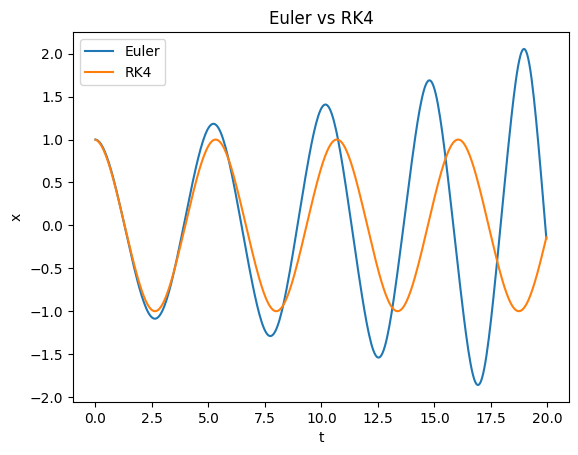

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def f(x, v, alpha):
    return v, -x - alpha*x**3

alpha = 0.5
dt = 0.05
N = 400

x_e, v_e = 1.0, 0.0
x_rk, v_rk = 1.0, 0.0

x_e_list, x_rk_list, t_list = [], [], []

for i in range(N):
    t = i*dt

    # Euler
    dx, dv = f(x_e, v_e, alpha)
    x_e += dt*dx
    v_e += dt*dv

    # RK4
    k1x, k1v = f(x_rk, v_rk, alpha)
    k2x, k2v = f(x_rk + 0.5*dt*k1x, v_rk + 0.5*dt*k1v, alpha)
    k3x, k3v = f(x_rk + 0.5*dt*k2x, v_rk + 0.5*dt*k2v, alpha)
    k4x, k4v = f(x_rk + dt*k3x, v_rk + dt*k3v, alpha)

    x_rk += (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
    v_rk += (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)

    x_e_list.append(x_e)
    x_rk_list.append(x_rk)
    t_list.append(t)

plt.plot(t_list, x_e_list, label="Euler")
plt.plot(t_list, x_rk_list, label="RK4")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Euler vs RK4")
plt.legend()

plt.savefig("Euler_vs_RK4.pdf")
plt.show()

files.download("Euler_vs_RK4.pdf")